# Amazon Customer Sales — Exploratory & Time-Series Analysis

## Introduction

This project analyzes Amazon customer order data to understand **sales performance, revenue trends, and monthly ordering patterns** over time.

The analysis uses Python and Pandas to explore yearly and monthly revenue, identify the strongest-performing periods, evaluate revenue growth, investigate recurring monthly patterns, and detect months with unusually high or low order volumes.

The goal is to transform transactional sales data into **business-focused insights** that can support decisions related to sales planning, promotional timing, inventory management, and performance monitoring.

### Business Questions

1. Which month generated the highest revenue in each year?
2. Which year achieved the highest overall revenue?
3. Is revenue consistently growing over time?
4. Are there recurring monthly revenue patterns?
5. Which months experienced unusually high order volumes?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Amazon_cleaned.csv")

In [3]:
df_copy = df.copy()

In [4]:
df_copy.head(5)

,OrderID,OrderDate,OrderYear,OrderMonth,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,...,GrossAmount,DiscountedAmount,NetAmount,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,2023,January,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,...,319.77,0.00,319.77,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,2023,December,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,...,251.37,12.57,238.80,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,2022,May,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,...,105.09,10.51,94.58,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,2023,July,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,...,167.90,25.18,142.72,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,2023,February,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,...,1031.28,257.82,773.46,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


## Month generated the highest revenue

In [5]:
month = df_copy.groupby(["OrderYear","OrderMonth"])["TotalAmount"].sum()
month.loc[month.groupby(level=0).idxmax()]

OrderYear  OrderMonth
2020       August        1640874.93
2021       July          1596668.40
2022       January       1609759.87
2023       May           1588151.65
2024       May           1642609.94
Name: TotalAmount, dtype: float64

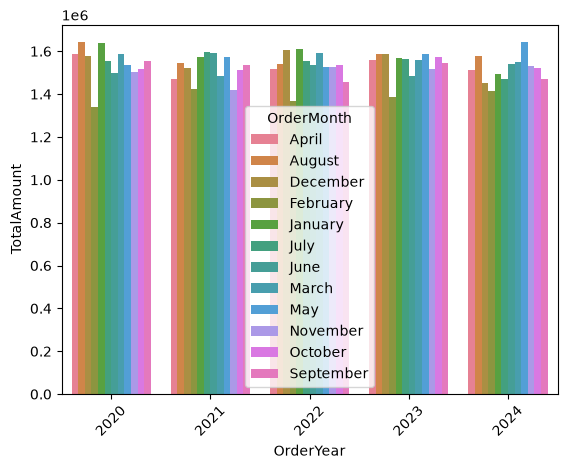

In [6]:
month = df_copy.groupby(["OrderYear","OrderMonth"])["TotalAmount"].sum().reset_index()
sns.barplot(data=month,
            x="OrderYear",
            y="TotalAmount",
            hue="OrderMonth")
plt.xticks(rotation=45)
plt.show()

## Yearly Revenue Performance

In [7]:
best_year = df_copy.groupby("OrderYear")["TotalAmount"].sum().nlargest(1)
print("Year that perform best =",best_year)

Year that perform best = OrderYear
2020    18529864.02
Name: TotalAmount, dtype: float64


## Revenue Growth Analysis

In [8]:
yearly_revenue = df_copy.groupby("OrderYear")["TotalAmount"].sum()
(yearly_revenue.pct_change()*100).round(2)

OrderYear
2020     NaN
2021   -1.52
2022    0.65
2023    0.80
2024   -1.88
Name: TotalAmount, dtype: float64

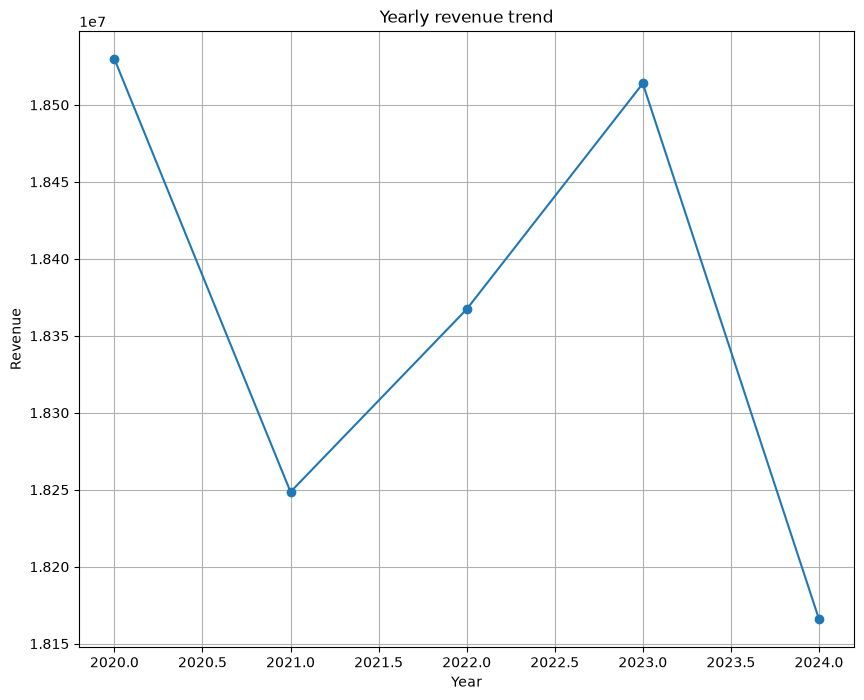

In [9]:
yearly_revenue.plot(figsize=(10,8),marker = "o")
plt.title("Yearly revenue trend")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

## Monthly Revenue Patterns

In [10]:
seasonality = df_copy.pivot_table(
    values="TotalAmount",
    index="OrderMonth",
    columns="OrderYear",
    aggfunc="sum"
)

seasonality

OrderYear,2020,2021,2022,2023,2024
OrderMonth,,,,,
April,1588347.29,1470885.02,1515497.24,1560322.12,1511151.55
August,1640874.93,1545324.30,1541701.50,1585424.79,1577272.85
December,1577655.06,1520160.14,1604276.23,1587813.81,1451073.77
February,1339388.21,1425365.99,1369866.29,1384957.09,1412146.91
January,1637069.40,1575253.23,1609759.87,1567772.07,1493946.70
July,1552981.94,1596668.40,1556516.29,1562298.78,1469460.10
June,1500269.29,1593398.08,1533829.81,1485367.09,1541772.48
March,1587125.66,1484165.89,1589809.35,1557146.56,1548280.27
May,1533834.17,1571842.25,1527845.26,1588151.65,1642609.94


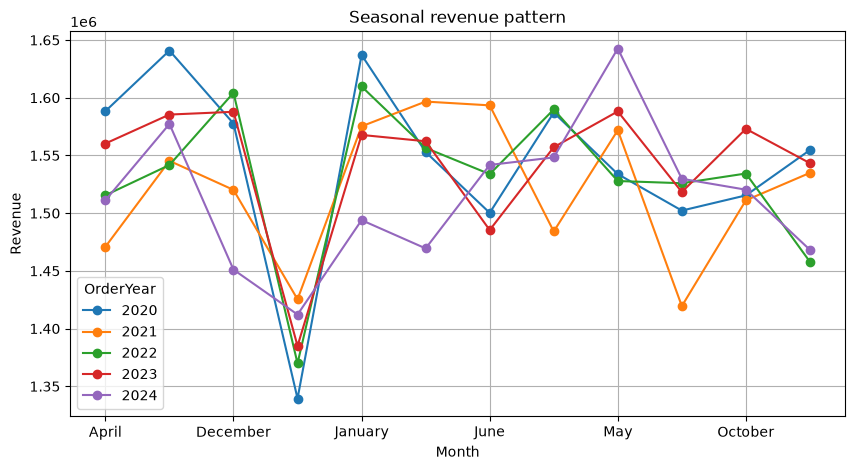

In [11]:
seasonality.plot(figsize=(10,5),marker='o')
plt.title("Seasonal revenue pattern")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

## Unusual Order Volume Analysis

In [12]:
monthly_order = df_copy.groupby(["OrderYear","OrderMonth"])["Quantity"].size()
z_score = (monthly_order-monthly_order.mean())/monthly_order.std()
monthly_order[abs(z_score)>2]


OrderYear  OrderMonth
2020       February      1490
2021       February      1516
2022       February      1510
2023       February      1540
Name: Quantity, dtype: int64

## Key Findings

### Revenue Performance

* **2020 was the strongest-performing year**, generating approximately **18.53M** in total revenue.
* The highest-revenue month varied by year:

  * **2020:** August — 1.64M
  * **2021:** July — 1.60M
  * **2022:** January — 1.61M
  * **2023:** May — 1.59M
  * **2024:** May — 1.64M
* **August 2020 recorded the highest monthly revenue** in the dataset at approximately **1.64M**, narrowly exceeding May 2024.

### Revenue Growth

Year-over-year revenue growth was inconsistent:

* **2021:** -1.52%
* **2022:** +0.65%
* **2023:** +0.80%
* **2024:** -1.88%

This indicates that revenue did **not follow a consistent upward trend** during the period analyzed. Revenue recovered slightly in 2022 and 2023 but declined again in 2024.

### Monthly Patterns

Monthly revenue varied across years, with some months repeatedly performing better than others. However, the strongest month changed from year to year, suggesting that there is **no single consistently dominant month** across the entire period.

Notably, **May performed particularly strongly in 2023 and 2024**, while August and January also recorded strong revenue in several years.

### Unusual Order Volume Analysis

The analysis identified **February as a consistently low-order-volume month**. Monthly order counts for February were approximately 1,490–1,540 orders across the analyzed years and were flagged as unusually low using the Z-score method.

This pattern is also consistent with the revenue analysis, where February recorded the lowest monthly revenue across all years. The results suggest a recurring seasonal decline in customer purchasing activity during February.


# Conclusion

The time-series analysis provides several useful insights into Amazon's sales performance over the period analyzed.

**2020 was the strongest year overall**, generating approximately **18.53M in revenue**. At the monthly level, **August 2020 recorded the highest monthly revenue at approximately 1.64M**, while May emerged as a particularly strong month in the later years, reaching approximately 1.64M in 2024.

The revenue trend, however, was **not consistently upward**. Revenue declined by 1.52% in 2021, followed by modest growth in 2022 and 2023, before declining again by 1.88% in 2024. This suggests that the business experienced fluctuations rather than sustained year-over-year growth.

The monthly analysis also identified differences in performance across the year, although the highest-performing month changed from year to year. This indicates that sales activity may be influenced by changing demand patterns rather than a single fixed seasonal peak.

Finally, **February consistently showed unusually high order volume from 2020 through 2023**, making it an important period for further investigation. Understanding what drives this recurring increase in orders could help with inventory planning, promotional campaigns, staffing, and operational capacity.

Overall, the analysis demonstrates how Python-based exploratory and time-series analysis can be used to move from raw transactional data to **actionable business insights**, while also highlighting areas that could be investigated further in a more advanced analysis.
